# ASOS 1-minute airport data: fetch, convert, resample

True per-minute precipitation (not hourly running totals), temperature, wind
and precipitation type for NYC's ASOS airport stations, from the Iowa
Environmental Mesonet 1-minute archive
(https://mesonet.agron.iastate.edu/request/asos/1min.phtml). No API key; needs
network access. The archive lags real time by 18-36 hours.

All steps are `src/fetch/asos_functions.py`. For the curated OpenMesh ASOS
record use `openmesh_data.ipynb`.

In [1]:
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent / "src"))
from fetch import asos_functions as asos

## Configuration

In [2]:
STATION_IDS = ["JFK", "LGA", "NYC"]           # IEM IDs; NYC is Central Park
START, END = datetime(2024, 1, 1), datetime(2024, 1, 30)
RESAMPLE = "5min"                             # any pandas offset: "10min", "1h", ...
OUTPUT_DIR = Path("../data/noaa_asos")        # projects/openmesh_nyc/data/, git-ignored

## Fetch and convert

Monthly requests per station, merged; then °F → °C, knots → m/s,
inches → mm, and the raw `ptype` code mapped to a category (dry, rain, snow,
...).

In [3]:
raw = asos.fetch_all_stations_1min(STATION_IDS, START, END, verbose=False)
minute = asos.process_all_stations(raw, verbose=False)
asos.station_summary(minute)

,rows,start,end,precip_mm,wet_rows,temp_c_mean,wind_ms_mean
station_id,,,,,,,
JFK,40240,2024-01-01,2024-01-29 23:59:00,147.32,512,2.33,5.85
LGA,41036,2024-01-01,2024-01-29 23:59:00,158.24,502,2.85,5.53
NYC,34333,2024-01-01,2024-01-29 23:59:00,105.66,391,3.11,3.17


## Precipitation type

Snow days matter: tipping buckets under-catch snow, so rain totals on those
days are a lower bound.

In [4]:
asos.get_precip_type_summary(minute, verbose=False)

,station_id,type,count
0,JFK,dry,32284
1,JFK,rain,3709
2,JFK,missing,1929
3,JFK,snow,1225
4,JFK,precip,1093
5,LGA,dry,33276
6,LGA,rain,4335
7,LGA,snow,1510
8,LGA,precip,1167
9,LGA,missing,748


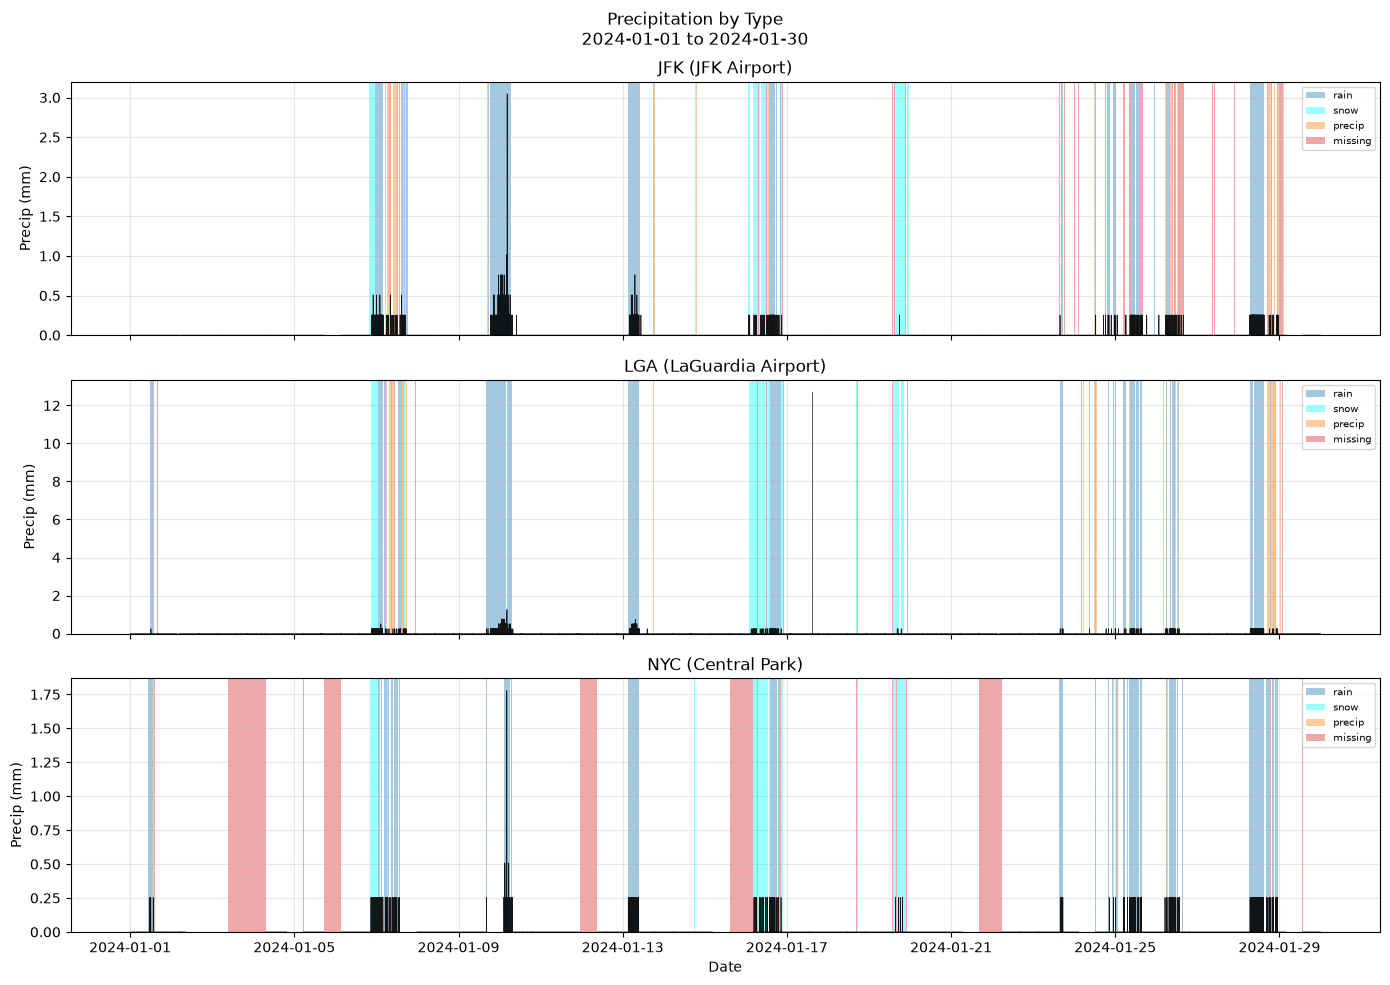

In [5]:
asos.plot_precip_by_type(minute, start_date=START, end_date=END)
plt.show()

## Weather and accumulation

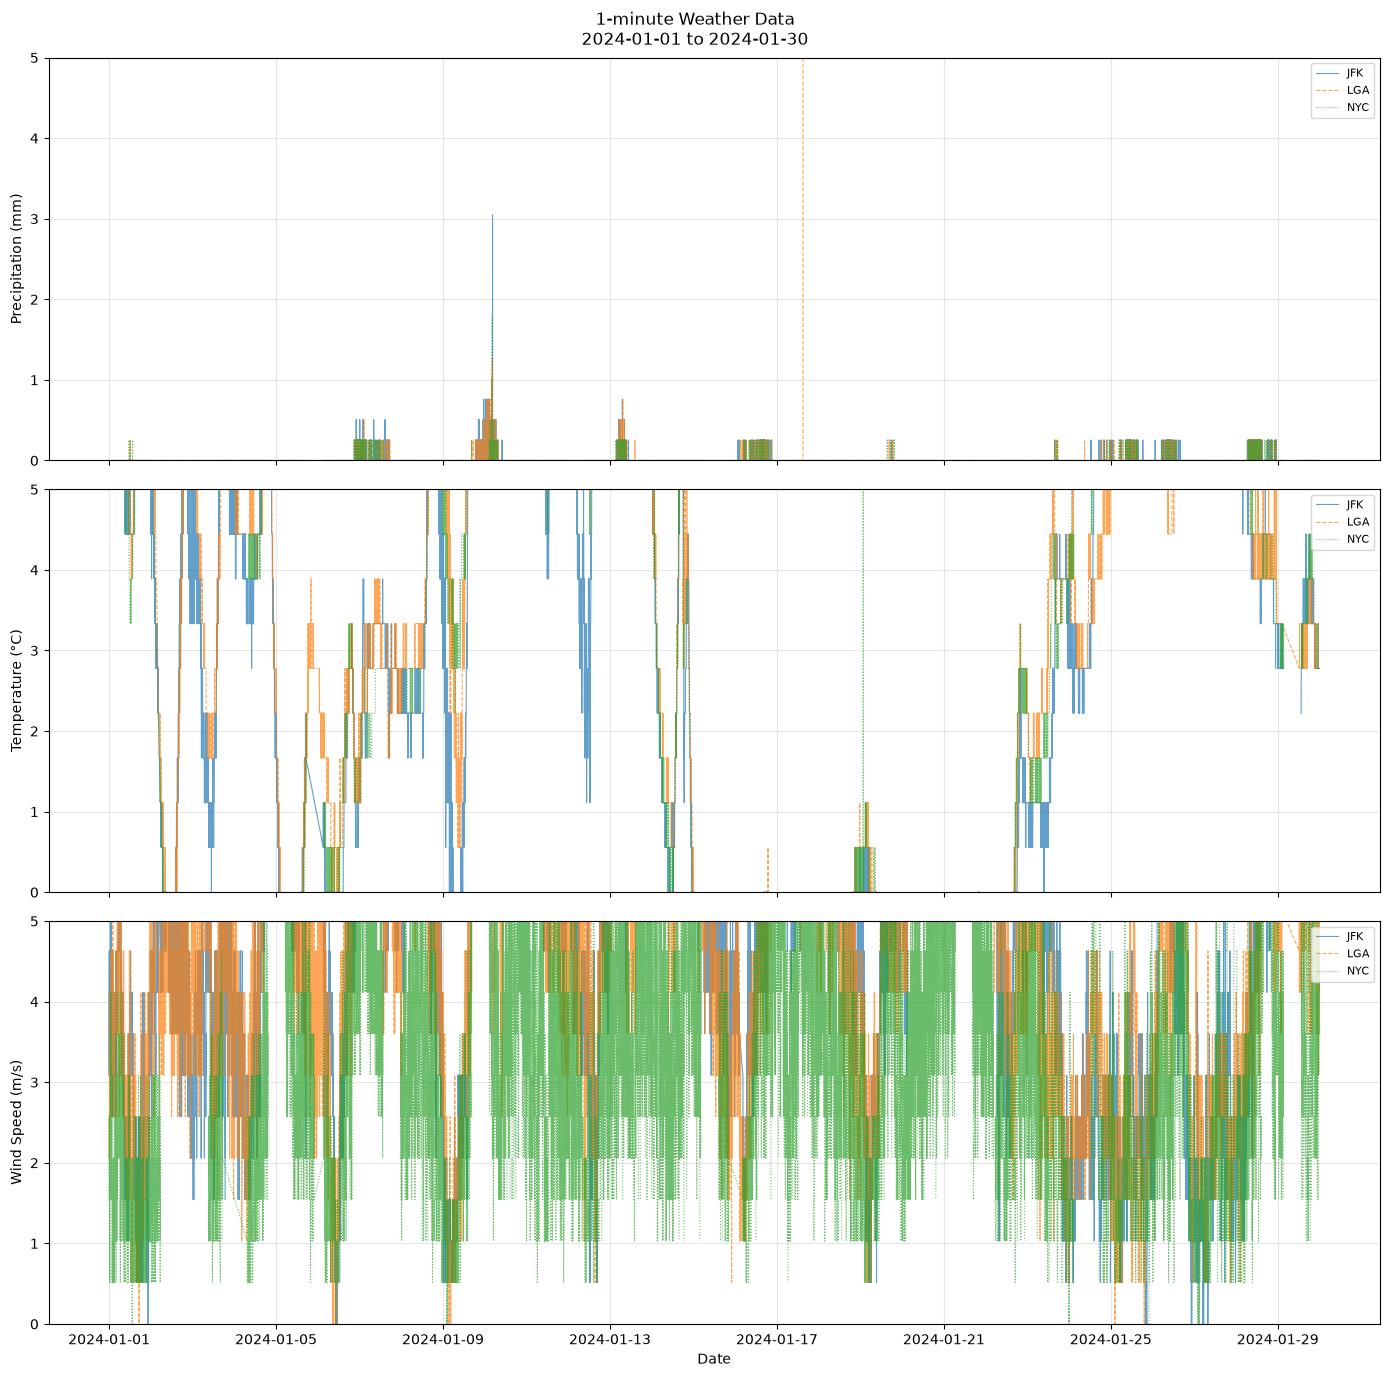

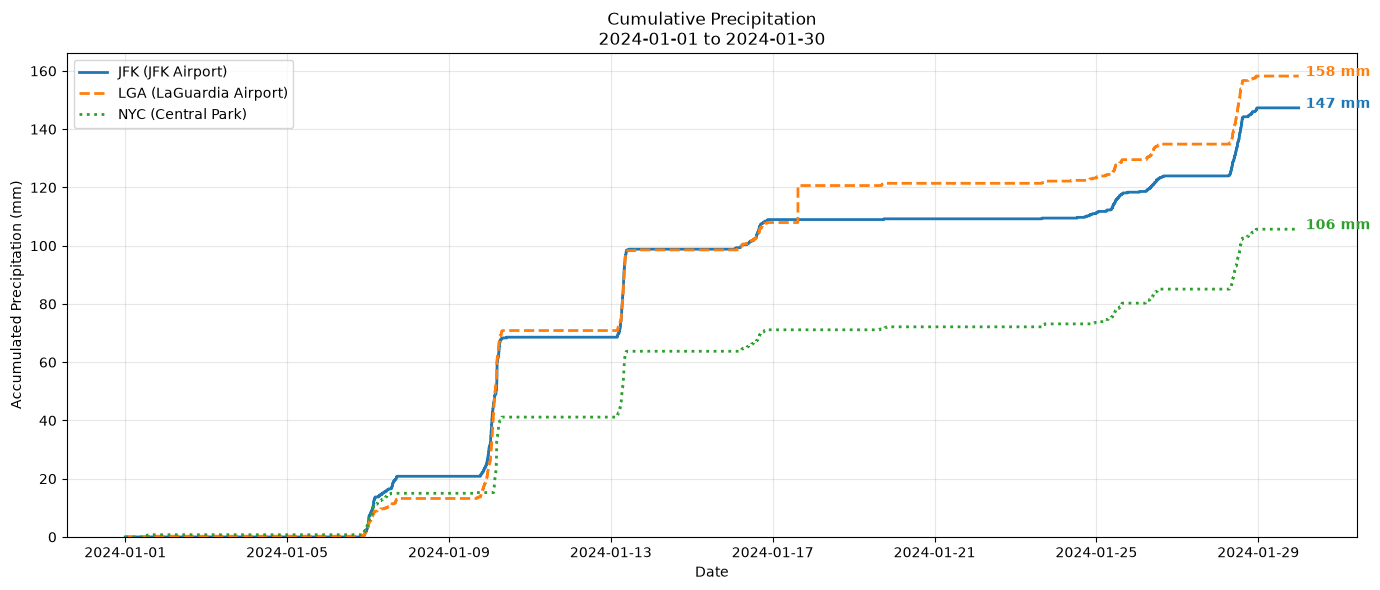

In [6]:
asos.plot_weather_subplots(minute, params=["precip_mm", "temp_c", "wind_speed_ms"],
                          start_date=START, end_date=END, figsize=(14, 14),
                          ylims=[0, 5], title_prefix="1-minute")
plt.show()
asos.plot_accumulated(asos.compute_accumulated_all(minute, START, END),
                      start_date=START, end_date=END)
plt.show()

## Resample

Summed precipitation, so totals must match the 1-minute data.

In [7]:
resampled = asos.resample_all_stations(minute, interval=RESAMPLE, verbose=False)
check = asos.station_summary(minute)[["precip_mm"]].join(
    asos.station_summary(resampled)[["precip_mm"]], rsuffix=f"_{RESAMPLE}")
assert (check.iloc[:, 0] - check.iloc[:, 1]).abs().max() < 1e-6
check

,precip_mm,precip_mm_5min
station_id,,
JFK,147.32,147.32
LGA,158.24,158.24
NYC,105.66,105.66


## Save

CSV per station and combined, into `OUTPUT_DIR`. Off by default.

In [8]:
SAVE = False
if SAVE:
    for prefix, data in {"1min": minute, RESAMPLE: resampled}.items():
        asos.save_data(data, OUTPUT_DIR, prefix=prefix)